In [2]:
# @title Library installation {"vertical-output":true}
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

import numpy as np
import gdown
import torch

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import sys
import os

path = '/content/drive/My Drive/MOR/Assignment 2'

if path not in sys.path:
    sys.path.append(path)

Mounted at /content/drive


#**Assignment 2 - Material design for a stunt training facility**

Considering an ideal, isolated portion of the floor, the behaviour is modelled using the equations of linear elasticity. The portion of floor under study is denoted as $\Omega = (0,1)^2$.

Specifically, the  external force representing the localized vertical impact exerted by an athlete’s foot during contact with the floor is modelled as:

$$
f(t) :=
\begin{cases}
\begin{bmatrix}
0, -5 \sin(2\pi t)
\end{bmatrix} & \text{for } 0 \leq t \leq 0.5 \\
\begin{bmatrix}
0, 0
\end{bmatrix} & \text{for } t > 0.5
\end{cases}
$$

Set the final time to be $T = 1$. Let $u : \Omega \times [0,T] \to \mathbb{R}^2$ be the vector-field describing the local
 displacement of the floor over time. We model $u$ as the solution to:

$$
\left\{
\begin{align}
&\frac{\partial^2 \mathbf{u}}{\partial t^2} = \nabla \cdot \left[ \lambda \nabla \cdot \mathbf{u} + \mu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \right] + \mathbf{g} && \text{in } \Omega \times (0, T] \\
&\mathbf{u}(\cdot, 0) \equiv \mathbf{0} && \text{in } \Omega \\
&\mathbf{u} \equiv \mathbf{0} && \text{on } \Gamma_{\text{bottom}} \times [0, T] \\
&\lambda (\nabla \cdot \mathbf{u}) \cdot \mathbf{n} + \mu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \cdot \mathbf{n} \equiv \mathbf{f} && \text{on } \Gamma_{\text{top}} \times [0, T] \\
&\lambda (\nabla \cdot \mathbf{u}) \cdot \mathbf{n} + \mu \left( \nabla \mathbf{u} + \nabla \mathbf{u}^\top \right) \cdot \mathbf{n} \equiv \mathbf{0} && \text{on } \partial\Omega \setminus (\Gamma_{\text{bottom}} \cup \Gamma_{\text{top}}) \times [0, T]
\end{align}
\right.
$$

Where $g = [0, -1]^T$ is a fixed body force (caused by the floor own weight). The Lamé coefficients of the material are given as:
$$
\lambda(x,y) =
\begin{cases}
10 & \text{if } y \geq \delta \\
50 & \text{if } y < \delta
\end{cases}
\quad \text{and} \quad
\mu(x,y) =
\begin{cases}
10 & \text{if } y \geq \delta \\
50 & \text{if } y < \delta
\end{cases}
$$

where $\delta = [0.5, 0.9]$ is a parameter describing the thickness of the two layers composing the floor.

Let $\mu := \delta$ be the 1-dimensional parameter describing the system. It is given access to a dataset consisting of $N = 100$ pre-computed random simulations, $\{\mu_i,u_{\mu_i}\}^N_{i=1}$, obtained for different values of
the problem parameter. The dataset was constructed by drawing random values of $\mu$, independently and uniformly in the parameter space, and by solving the corresponding equations of linear elasticity using Finite Element in space and finite differences in time. In particular, each PDE solution is being represented as a matrix, $u_{\mu_i}$, listing $Nt = 51$ time snapshots equally spaced in time ($\Delta t = 0.02$), each with $Nh = 3362$ degrees of freedom

# Task 1
Data must be split in two blocks, keeping 75 simulations for training and 25 for testing. Then a suitable approach between POD-NN, DL-ROM and AE+SINDy must be chosen and the corresponding reduced order model must be implemented.
The performances of the ROM is evaluated in terms of the following error metric (test average of relative space-time L2 errors):

</br>$$
\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}}
\left[
\frac{
\left\| \sum_{j=1}^{N_t} \left( \mathbf{u}_{i,j}^{\text{test}} - \tilde{\mathbf{u}}_{i,j}^{\text{test}} \right) \right\|_{L^2(\Omega)}
}{
\left\| \sum_{j=1}^{N_t} \mathbf{u}_{i,j}^{\text{test}} \right\|_{L^2(\Omega)}
}
\right]
$$</br>
where $u_{i,j}^{test}$ is the j-th time step of the i-th test simulation and $\tilde{u}^{test}_{i,j}$ is the corresponding ROM approximation.The ROM is considered satisfactory if the error in the previous equation is below 2.5%.



In [4]:
# @title Mesh definition and data loading
# FOM discretization
mesh = fe.unitsquaremesh(40, 40)
Vh = fe.space(mesh, 'CG', 1, vector_valued = True)
clc()
download_data = False
if download_data:
  # Dataset (parameters and FOM simulations)
  gdown.download(id = "1XYPnIpVVc9jkd7LwMhC-FYoV2RTnTK8L", output = "floor.npz")
  clc()
  data = np.load("floor.npz")
else:
  data = np.load(os.path.join(path, 'floor.npz'))
mu, u = dv.tensor(data['mu'], data['u'])

clc()

In [5]:
# @title Data shape

ns, nt, nh = u.shape
t = list(np.linspace(0, 1, nt))

# Division in train and test
p = mu.shape[-1]
print("Trajectories:\t%d." % ns) # ns = 100
print("Timesteps:\t%d." % nt) # nt = 51
print("FOM dimension:\t%d." % nh) # nh = 3362
print("Parameters:\t%d." % p) # p = 1

Trajectories:	100.
Timesteps:	51.
FOM dimension:	3362.
Parameters:	1.


## Definition of a new parameter and reshaping
Since time is treated as a further parameter, in oder to train the NN a new parameter vector must be defined as

$$\texttt{mut}_{i,j, .} = [\mu_i,\;t_j]$$

where $t_{j}=jT/N_t$ and $\texttt{mut}\in\mathbb{R}^{n_s\times n_t\times (p+1)}$.

Then the datasets $\texttt{u}$ and $\texttt{mut}$ are reshaped to be of the form $\mathbb{R}^{(n_sn_t)\times n_h}$ and $\mathbb{R}^{(n_sn_t)\times (p+1)}$, respectively.

In [6]:
# @title Time-extended parameter vector
mut = dv.zeros(ns, nt, p+1)
times = dv.tensor(np.linspace(0, 1, nt))
for i in range(ns):
    mut[i,:,0] = mu[i]
    mut[i,:,1] = times

ntrain = 75*nt;
u = u.reshape(-1, nh)
mut = mut.reshape(-1, p+1)

## POD
By performing the SVD of the Snapshots matrix $\mathbb{S}$ it's possible to plot the Singular Values decay:

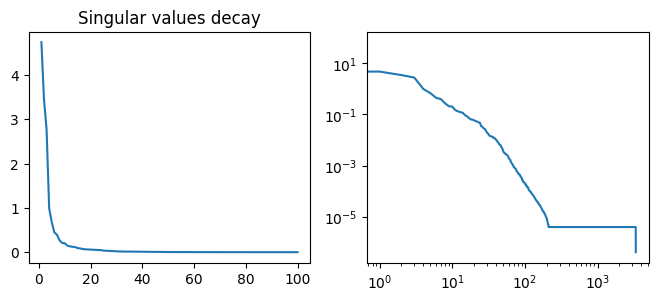

In [7]:
# @title Singular Values Decay
# POD
from scipy.linalg import svd
import matplotlib.pyplot as plt

X, s, _ = svd(u[:ntrain].T.cpu().numpy(), full_matrices = False)
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
plt.plot(1+np.arange(100), s[1:101])
plt.title("Singular values decay")
plt.subplot(1, 2, 2)
plt.loglog(s)
plt.show()

Since the decay is quite fast, the problem can be considered easily reducible.

POD-NN is a good choice, as it combines POD dimensionality reduction and Neural Networks to learn a map from the parameter space to the solutions in the reduced space.
The algorithm can be synthesized as follows:

  - Collect FOM snapshots and build the snapshots matrix $\mathbb{S}$ of dimension $\mathbb{R}^{n_h\times(n_s\times n_t)}$

  - Compute the POD basis $\mathbb{V}$ via SVD of the snapshots matrix

  - Construct a new dataset $\{\boldsymbol{\mu}_i, \mathbf{u}_{N}(\boldsymbol{\mu}_i)\}_{i=1}^{n}$, consisting of parameter instances and POD coefficients, via projection $\mathbf{u}_{N}:=\mathbb{V}^\top \mathbf{u}_h$;

  - Design and train a neural network $\phi:\mathbb{R}^{p+1}\to\mathbb{R}^{N}$ so that $\phi(\mu_i,t_j)\approx \mathbf{u}_{N}(\mu_i,t_j)$;

  - Define the ROM solution as $ \mathbf{u}_{ROM}= \mathbb{V}\phi(\boldsymbol{\mu})$.

In [8]:
# @title Energy captured by the first 10 modes
r = 10
energy = (s[0:r]**2).sum()/(s[0:]**2).sum()
print('n =',r,' energy =', energy)
V = dv.tensor(X[: , :r])

n = 10  energy = 0.99996495


Since the first ten modes capture more than 99.99% of the system, the chosen dimension of the reduced space is 10.
It is then possible to compute the projection error as:

</br>$$E_{\text{proj}}=\frac{1}{N_{\text{test}}}\sum_{i=1}^{N_\text{test}}\frac{|\mathbf{u}_{i}^{\text{test}}-\mathbf{V}\mathbf{V}^{\top}\mathbf{u}_{i}^{\text{test}}|}{|\mathbf{u}_{i}^{\text{test}}|}$$</br>

In [9]:
# @title Projection error
l2 = L2(Vh)
l2.cuda()
clc()

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, nt).sum(axis = -1)/l2(utrue).reshape(-1, nt).sum(axis = -1)).mean()

avg_proj_error = error(u[ntrain:], u[ntrain:] @V @V.T)
print("Average projection error: %s." % num2p(avg_proj_error))

Average projection error: 0.77%.


Then the NN $\phi$ must be designed and trained, however it is first needed to create the training dataset, namely $\{\boldsymbol{\mu}_i, \mathbf{u}_{N}(\boldsymbol{\mu}_i)\}_{i=1}^{n}$.

To this purpose, $\mathbf{u}_N(\boldsymbol{\mu}_i)$ must be computed as $\mathbf{u}_N(\boldsymbol{\mu}_i) = \mathbb{V}^\top\mathbf{u}_h(\boldsymbol{\mu}_i)$.

In [10]:
# @title Building $\mathbf{u}_N$  for the NN training
c = u @ V
c = c.reshape(-1,r)

## NN architecture and training
Then, the Neural Network must be defined and trained.
The chosen architecture has 4 layers, input dimension equal to the number of parameters plus one (time included) and overall output dimension equal to 10, the dimension of the reduced space.

In [11]:
train = False
phi = DFNN(Dense(p+1, 50, gelu) + Dense(50, 100, gelu) + Dense(100, 50, gelu) + Dense(50, r, activation = None))
phi.cuda()
phi.He()

if train:
  phi.train(mut, c, ntrain = ntrain, epochs = 300, loss = mse(euclidean))
  phi.freeze()
  phi.save(os.path.join(path, 'Weights_POD_NN'))
else:
  phi.load(os.path.join(path, 'Weights_POD_NN'))
  phi.freeze()

## Error (accuracy)
The performance of the ROM is evaluated in terms of the following error metric (test average of relative space-time L2 errors):

</br>$$
E=\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}}
\left[
\frac{
\left\| \sum_{j=1}^{N_t} \left( \mathbf{u}_{i,j}^{\text{test}} - \tilde{\mathbf{u}}_{i,j}^{\text{test}} \right) \right\|_{L^2(\Omega)}
}{
\left\| \sum_{j=1}^{N_t} \mathbf{u}_{i,j}^{\text{test}} \right\|_{L^2(\Omega)}
}
\right]
$$

In [12]:
# @title Error computation
uROM = lambda mt: phi(mt)@V.T
print("Average relative error of POD-NN: %s." % num2p(error(u[ntrain:], uROM(mut[ntrain:]))))

Average relative error of POD-NN: 2.15%.


## POD-DL-ROM
Since POD dimensionality reduction works well, it is also possible to exploit it combined with an autoencoder.
Differently from POD-NN, the dimensionality reduction is not carried out entirely by the POD. The procedure can be summed up as follows:
- First (linear) dimensionality reduction through POD (higher number of modes selected)
- Second (nonlinear) dimensionality reduction though an encoder $\Psi'$ (NN), taking as input the solutions projected into the POD basis and giving as output the solution in the latent dimension
- The latent solution is then represented in the POD space exploiting the decoder $\Psi$ and, from the latter space, the solution is then projected to the FOM space through the POD basis matrix.
- Once the autoencoder (encoder + decoder) is trained (comparing its outputs to the real solutions projected in the POD space), another feedforward NN is defined from the extended parameter space to the latent space: $\phi ':\mathbb{R}^{p+1}\to\mathbb{R}^{N}$

Starting by considering the first 50 modes, it is possible to project the solutions $\mathbf{u}_r = \mathbb{V}^\top \mathbf{u}_h$ and train the autoencoder.
The chosen latent dimension is 5.


In [13]:
# @title Autoencoder definition and training
n_r = 50
V_dl = X[:,:n_r]
V_dl=dv.tensor(V_dl)
u_r = u @ V_dl

from torch.optim import Adam

rho_e = lambda x: relu(x) -10*relu(-x)
rho_d = lambda x: relu(x) -0.1*relu(-x)
latent = 5
train = False

encoder = Dense(n_r, 40, rho_e) + Dense(40, 30, rho_e) + Dense(30, 10, rho_d) + Dense(10, latent, rho_e)
decoder = Dense(latent, 10, rho_d) + Dense(10, 20, rho_d)+ Dense(20, 30, rho_d) + Dense(30, 40, rho_d) + Dense(40, n_r, activation = None)
autoencoder = DFNN(encoder + decoder)

autoencoder.He()
autoencoder.cuda()

if train:
  autoencoder.train(u_r, u_r, loss = mse(euclidean), ntrain = ntrain, epochs = 250)
  autoencoder.train(u_r, u_r, ntrain = ntrain, loss = mse(euclidean), epochs = 200, optim = Adam, lr = 1e-5, batchsize = 64)

  autoencoder.freeze()
  autoencoder.save(os.path.join(path, 'Weights_POD_DL_ROM'))
else:
  autoencoder.load(os.path.join(path, 'Weights_POD_DL_ROM'))
  autoencoder.freeze()

from dlroms.dnns import Matrix
full_encoder = Matrix(V_dl.T) + encoder
full_decoder = decoder + Matrix(V_dl)
ae = full_encoder + full_decoder

It is then possible to assess the performance of the autoencoder (which is not the same of the entire ROM)  in terms of the following error metric (test average of relative space-time L2 errors):

</br>$$
E=\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}}
\left[
\frac{
\left\| \sum_{j=1}^{N_t} \left( \mathbf{u}_{r,i,j}^{\text{test}} - \tilde{\mathbf{u}}_{r,i,j}^{\text{test}} \right) \right\|_{L^2(\Omega)}
}{
\left\| \sum_{j=1}^{N_t} \mathbf{u}_{r,i,j}^{\text{test}} \right\|_{L^2(\Omega)}
}
\right]
$$
where $\mathbf{u}_r = \mathbb{V}^\top\mathbf{u}_h$

In [14]:
# @title Autoencoder mean relative error (L2 norm)
print("Autoencoder MRE: %s" % num2p(error(u[ntrain:], ae(u[ntrain:]))))

Autoencoder MRE: 1.87%


In [15]:
# @title POD projection error (L2 norm)
print("POD MRE: %s" % num2p(error(u[ntrain:], u[ntrain:] @ V_dl @ V_dl.T)))

POD MRE: 0.03%


By comparing it with the POD projection error, it can be noticed that the POD dimensionality reduction affects the quality of the approximation way less than the autoencoder.

Now the second Neural Network $\phi'$ can be trained, so to learn a map from the extended parameter space to the latent space.

In [16]:
# @title Definition and training of $\phi '$
nu = full_encoder(u)
train2 = False

phi2 = DFNN(Dense(p+1, 30, gelu) + Dense(30, 50, gelu) + Dense(50, 100, gelu) + Dense(100, 50, gelu) + Dense(50, 30, gelu) + Dense(30, latent, activation = None))
phi2.He()
phi2.cuda()


if train2:
  phi2.unfreeze()
  phi2.train(mut, nu, ntrain = ntrain, epochs = 350, loss = mse(euclidean), optim = torch.optim.LBFGS)
  phi2.freeze()
  phi2.save(os.path.join(path, 'Weights_POD_DL_ROM_2'))
else:
  phi2.unfreeze()
  phi2.load(os.path.join(path, 'Weights_POD_DL_ROM_2'))
  phi2.freeze()

Once $\phi'$ is trained, the POD-DL-ROM can be defined:
$$\tilde{\mathbf{u}}_h = \mathbb{V}\psi(\phi'(\boldsymbol{\mu})) $$
And the error can be computed as before as:

</br>$$
E=\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}}
\left[
\frac{
\left\| \sum_{j=1}^{N_t} \left( \mathbf{u}_{i,j}^{\text{test}} - \tilde{\mathbf{u}}_{i,j}^{\text{test}} \right) \right\|_{L^2(\Omega)}
}{
\left\| \sum_{j=1}^{N_t} \mathbf{u}_{i,j}^{\text{test}} \right\|_{L^2(\Omega)}
}
\right]
$$

In [17]:
# @title Construction of the DL-ROM and error computation (L2 norm)
dlrom = lambda mt: full_decoder(phi2(mt))
print("Average relative error of POD-DL-ROM: %s." % num2p(error(u[ntrain:], dlrom(mut[ntrain:]))))

Average relative error of POD-DL-ROM: 2.79%.


# Task 2
Considering that the FOM requires $\approx$ 8.11 seconds to generate a single trajectory it is required to quantify the computational speed-up provided by the ROM.

In [19]:
# @title Time comparison between FOM and ROM
from time import perf_counter
t0 = perf_counter()
uROM(mut[0])
t1 = perf_counter()
dtROM = t1-t0
dlrom(mut[0])

speedup1 = 8.11/dtROM

print("POD-NN solver:\t1 call = %.2f ms" % (1000*dtROM))

t0 = perf_counter()
dlrom(mut[0])
t1 = perf_counter()
dtROM = t1-t0

print("POD-DL-ROM solver:\t1 call = %.2f ms" % (1000*dtROM))

speedup2 = 8.11/dtROM

print("FOM solver time = %.0f x POD-NN solver time" % speedup1)

print("FOM solver time = %.0f x POD-DL-ROM solver time" % speedup2)

POD-NN solver:	1 call = 1.03 ms
POD-DL-ROM solver:	1 call = 1.20 ms
FOM solver time = 7839 x POD-NN solver time
FOM solver time = 6773 x POD-DL-ROM solver time


# Task 3
It is required to study how the thickness of the rigid layer ($\delta$) affects the maximum deformation.
Considering the following functional:

$$
J(u):=\max_{(x,t)\in\Omega\times[0,T]} \vert\vert u(x,t)\vert\vert
$$

Leveraging the ROM, it is required to plot the map $\delta \to J(u_{\delta})$.

In [20]:
# @title Computation of the maximum deformations
nsamples = 1001
mu2 = dv.tensor(np.linspace(0.5,0.9,nsamples))
mut2 = dv.zeros(nsamples, nt, p+1)
for i in range(nsamples):
    mut2[i,:,0] = mu2[i]
    mut2[i,:,1] = times
u2 = uROM(mut2)
J_rom = dv.zeros(nsamples,1)
J_fom_tr = dv.zeros(75,1)
J_fom_te = dv.zeros(25,1)
u_tr = u[:ntrain].reshape(75,-1)
u_te = u[ntrain:].reshape(25,-1)
mu_tr = mu[:round(ntrain/nt)]
mu_te = mu[round(ntrain/nt):]
for i in range(nsamples):
    J_rom[i] = torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())
    if i < 75:
      J_fom_tr[i] = torch.max(u_tr[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())
    if i < 25:
      J_fom_te[i] = torch.max(u_te[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())


u3 = dlrom(mut2)
J_dl_rom = dv.zeros(nsamples,1)
u_tr = u[:ntrain].reshape(75,-1)
u_te = u[ntrain:].reshape(25,-1)
mu_tr = mu[:round(ntrain/nt)]
mu_te = mu[round(ntrain/nt):]
for i in range(nsamples):
    J_dl_rom[i] = torch.max(u3[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())

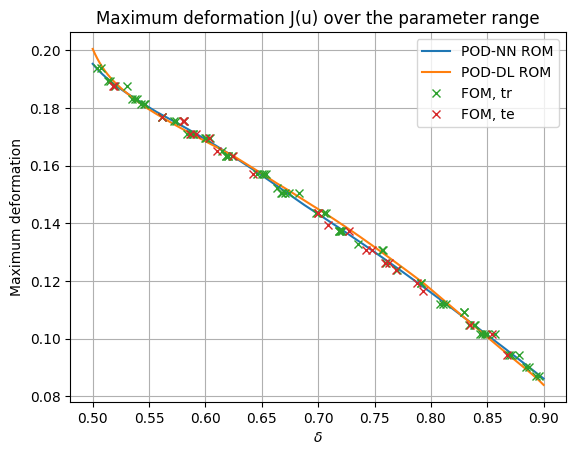

In [21]:
# @title Plot of the functional J
plt.figure()
plt.plot(mu2.cpu().numpy(),J_rom.cpu().detach().numpy(), label='POD-NN ROM')
plt.plot(mu2.cpu().numpy(),J_dl_rom.cpu().detach().numpy(), label='POD-DL ROM')
plt.plot(mu_tr.cpu().numpy(),J_fom_tr.detach().cpu().numpy(), 'x', label='FOM, tr')
plt.plot(mu_te.cpu().numpy(),J_fom_te.detach().cpu().numpy(), 'x', label='FOM, te')
plt.title('Maximum deformation J(u) over the parameter range')
plt.legend()
plt.xlabel('$\delta$')
plt.ylabel('Maximum deformation')
plt.grid(True)
plt.show()

# Task 4
To gain additional insights, the company also wants to study the behavior of the maximum deformation over time, given by the time-dependent functional:

$$
J_t(u):=\max_{x\in\Omega} \vert\vert u(x,t)\vert\vert
$$

It is required to pick 1001 equally spaced values of $\delta$ in $[0.5, 0.9]$. For each value of $\delta$, the map $t \to J_t(u_\delta)$.

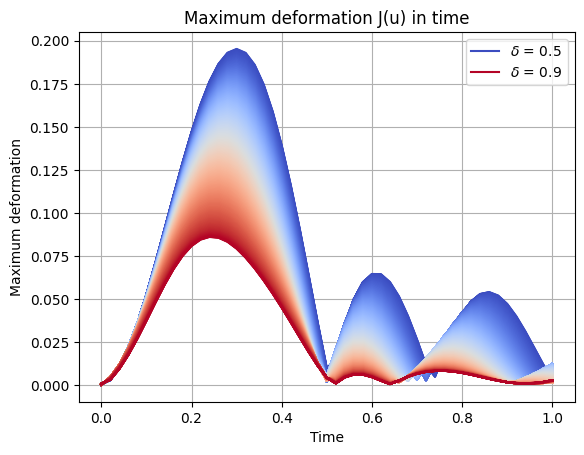

In [22]:
# @title Maximum deformation over time
plt.figure()
cmap = plt.cm.coolwarm  # blue to red
for i in range(nsamples):
    t_max = times[torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:]==torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())]
    color = cmap(i / (nsamples - 1))  # normalized between 0 and 1
    if i == 0:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color, label='$\delta$ = 0.5')
    elif i == nsamples-1:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color, label='$\delta$ = 0.9')
    else:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color)
      #plt.plot(t_max.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()).detach().cpu().numpy(),'.')
plt.legend()
plt.title('Maximum deformation J(u) in time')
plt.xlabel('Time')
plt.ylabel('Maximum deformation')
plt.grid(True)
plt.show()

It is possible to notice that time of maximum deformation decreases with delta

In [23]:
# @title Definition of a function for the animations
def animated_warp(u, Vh):
  from dlroms.gifs import save as savegif
  rnd = np.random.randint(50000)
  def drawframe(i):
    plt.figure(figsize = (4, 4))
    fe.plot(u[i], Vh, axis = [-0.25, 1.25, -0.25, 1.25], warp = True)
    plt.title("t = %.2f" % (i*0.02))
    plt.axis("off")
  savegif(drawframe, len(u), "temp%d-gif" % rnd)
  from PIL import Image, ImageSequence
  path = "temp%d-gif.gif" % rnd
  with Image.open(path) as im:
    frames = [frame.copy() for frame in ImageSequence.Iterator(im)]
    frames[0].save(path, save_all=True, append_images=frames[1:], loop=0, duration=im.info.get('duration', 100))
  from IPython.display import Image, display
  display(Image("temp%d-gif.gif" % rnd))
  from os import remove
  remove("temp%d-gif.gif" % rnd)

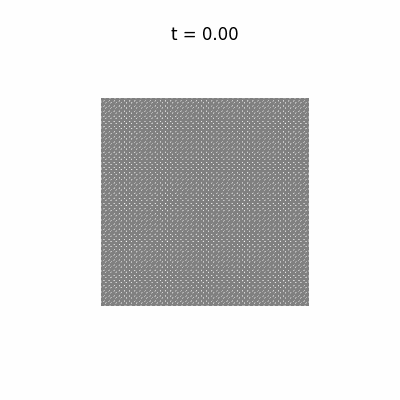

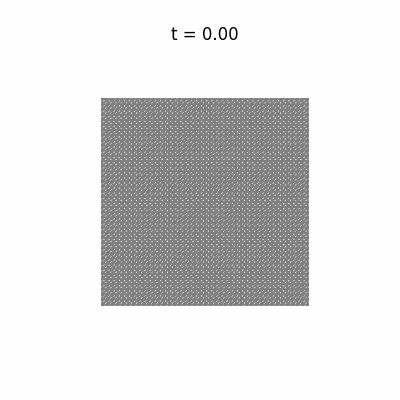

In [24]:
# @title Animation of maximum and minimum deformations
animated_warp(u2[0], Vh)
animated_warp(u2[-1], Vh)

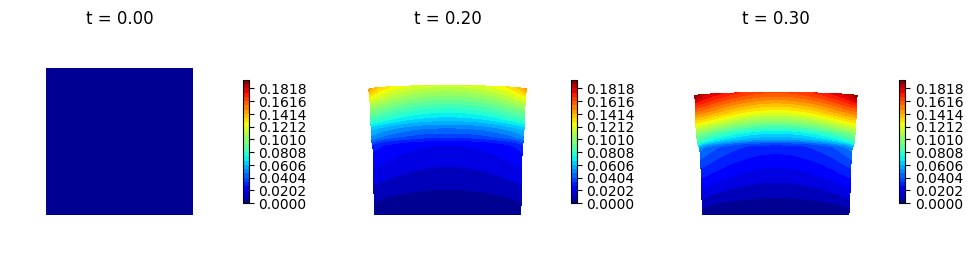

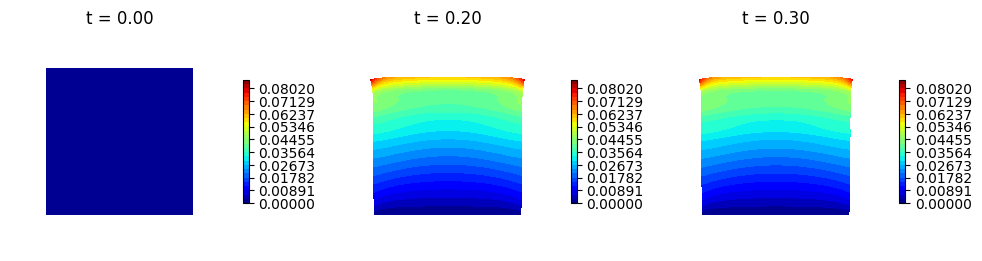

In [25]:
# @title Maximum and minimum deformations
which = 0 # First simulation

umod = u2[which].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()
plt.figure(figsize = (12, 4))
for i, ti in enumerate([0, 10, 15]):
  plt.subplot(1, 3, i+1)
  warped_mesh = fe.warpmesh(u2[which, ti], Vh)
  delta = mu[which].item()
  WVh = fe.space(warped_mesh, 'CG', 1)

  fe.plot(umod[ti], WVh, levels = 30, vmin = umod.min(), vmax = umod.max(), colorbar = True, shrink = 0.4)
  plt.axis([-0.25, 1.25, -0.25, 1.25])
  plt.title("t = %.2f" % t[ti])
  plt.axis("off")

which = -1 # First simulation

umod = u2[which].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()
plt.figure(figsize = (12, 4))
for i, ti in enumerate([0, 10, 15]):
  plt.subplot(1, 3, i+1)
  warped_mesh = fe.warpmesh(u2[which, ti], Vh)
  delta = mu[which].item()
  WVh = fe.space(warped_mesh, 'CG', 1)

  fe.plot(umod[ti], WVh, levels = 30, vmin = umod.min(), vmax = umod.max(), colorbar = True, shrink = 0.4)
  plt.axis([-0.25, 1.25, -0.25, 1.25])
  plt.title("t = %.2f" % t[ti])
  plt.axis("off")